# Do stocks that "crash with the market" pay you extra? — coskewness, in plain English 📉
### Bad hedges are supposed to be cheap (high expected return) — does that survive on the big stocks you own?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Coskewness_premium%3F: Busted](https://img.shields.io/badge/Coskewness_premium%3F-Busted-8b949e?style=flat-square)

There's a respectable, *real* idea in finance: a stock that tends to fall **hardest exactly when the whole market is falling hard** is a lousy thing to own — it lets you down right when you most need protection. Because nobody likes that, such names should be a little **cheap**, i.e. carry a small extra expected return as compensation. The fancy name for "falls with the market's tail" is **coskewness** (low / negative coskewness = the bad hedge). The trade writes itself: **buy the crash-sensitive names, short the insurance-like ones.**

It's a genuine factor in the broad market. This notebook asks the question a normal investor actually cares about: does it still pay on the **big, liquid** stocks in your account? The answer is a clean, slightly anticlimactic **almost-but-no** — the tilt leans the right way, but it's a coin.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The premium is small and lives in the *spread* of crash-sensitivity across thousands of names; yfinance gives us the big ones, so we run it on a fixed **S&P-100-style basket** and call it a **proxy** throughout. That basket is also made of *survivors* — which trims the very names whose crash risk came true. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from coskewness import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    PRICES = PRICES[PRICES.index <= ASOF]          # drop the partial 2026-06 bar
    # cache the (slow) rolling-coskewness panel so both notebooks build fast
    _cache_dir = os.path.abspath("../_cache")
    _qp = os.path.join(_cache_dir, "qret_q5.parquet")
    if os.path.exists(_qp):
        QRET = pd.read_parquet(_qp)
        PANEL = None
    else:
        PANEL = data.build_panel(PRICES)
        QRET = st.quintile_returns(PANEL)
        try:
            QRET.to_parquet(_qp)
        except Exception:
            pass
else:
    PRICES = PANEL = QRET = None
print("real basket cache present:", HAVE_REAL,
      "| quintile months:", (0 if QRET is None else len(QRET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-05-29', 'asof': '2026-05-31', 'days': 5385, 'years': 21.4, 'names': 79, 'fp': 'abdf2637ac09', 'n_months': 251, 'q1': (15.2, 19.3, 0.79), 'q2': (15.4, 16.3, 0.94), 'q3': (15.9, 15.6, 1.02), 'q4': (15.2, 15.4, 0.99), 'q5': (13.9, 15.5, 0.9), 'ls_gross': (1.3, 0.08, 0.4, 49, 0.352), 'ls_net': (-4.0, -0.25, -1.24, 42, None), 'robust': [('tertiles', -0.0, -0.0, 49), ('quintiles', 1.3, 0.4, 49), ('deciles', 2.5, 0.62, 54)], 'subs': [('2005-2015', 127, 1.9, 0.4), ('2016-2026', 124, 0.7, 0.17)], 'syn': [(0.0, 0.09, 0.05, 49, 0.479), (0.004, 13.43, 7.6, 73, 0.0)], 'syn_robust': [(0.0, 0.24, 1.08, 0.4, 1.71), (0.004, 8.58, 1.28, 13.77, 1.72)]}


real basket cache present: True | quintile months: 251


## The answer first

| Question | Answer |
|---|---|
| Do the crash-sensitive (low-coskew) stocks pay a premium over the insurance-like ones? | **Barely — and it's a tie statistically.** The crash-sensitive tail (Q1) returned **+15.2%/yr** vs the insurance-like tail (Q5)'s **+13.9%/yr** — the right direction, but a hair. |
| So the textbook trade (buy crash-sensitive, short insurance) makes money? | **Not reliably.** **+1.3%/yr** gross, which is **statistically indistinguishable from zero** (a coin-flip win-rate). |
| Then why is the original finding real and respected? | **Different universe.** It's priced off the *spread* in crash-sensitivity across the **whole** market — smaller, cyclical, leveraged names included. The big stocks here all behave fairly market-like, so the spread collapses. |
| And the survivors? | A surviving basket quietly **drops the names whose crash risk materialised** (they fell hardest and de-listed) — exactly the left tail the premium is meant to pay for. |

> The coskewness premium is real where the dispersion is. On the big liquid names, "crash-sensitive" stops meaning much, and the premium shrinks into the noise.

## 1 · The claim

> *"Each month, measure how each stock behaves **when the market makes a big move** — its **coskewness**. Some names reliably fall hardest in the market's worst stretches (low / negative coskewness): bad hedges. Investors dislike that, so those names are priced a little cheap and should **out-earn** going forward. Sort into five buckets by coskewness, buy the crash-sensitive bucket, short the insurance-like one."*

This is **Harvey & Siddique (2000)** — a real, well-cited risk factor (building on Kraus & Litzenberger's 1976 three-moment CAPM). Note the difference from its idiosyncratic cousin ([Study 503 — idio-skew](../503-expected-idiosyncratic-skewness/)): that one is the stock's *own* private tail (diversifiable); coskewness is the **shared** tail — how the name moves with the *market's* crashes. Opposite axis, opposite predicted sign.

## 2 · So what?

If the crash-sensitive tail really did pay a premium on the stocks everyone owns, the advice would be concrete: **you get paid to hold the bad hedges** — a clean third-moment risk premium beyond plain beta. But "low coskewness" can mean two different things depending on *which* stocks you sort. Across the **broad** market it picks out genuinely fragile, cyclical, leveraged names that deserve compensation. Across a handful of **mega-cap survivors** it picks out... not much — they all wobble with the market in fairly similar ways, and the ones that *truly* cracked are no longer in the basket. Same statistic, very different bite.

## 3 · How would we even know?

We rebuild the sort on a **transparent large-cap proxy**: a fixed **79-name S&P-100-style basket** (2005-01-03 → 2026-05-29, 21 years).

1. **Score each stock's crash-sensitivity.** Every month, measure how the stock moves when the **market** moves a lot — its coskewness over the past year (low / negative = a bad hedge).
2. **Sort into five buckets.** Q1 = most crash-sensitive (low coskew) … Q5 = most insurance-like (high coskew).
3. **See what happens next.** Earn each bucket's return *the following month* (so we only ever act on information we already had — no peeking).
4. **Run the trade.** Buy Q1, short Q5, and ask: does crash-sensitive-minus-insurance make money, lose money, or do nothing? If it does nothing, the coskewness premium doesn't survive on big stocks.

## 4 · The teardown — let's actually look

**First, the five buckets.** Average yearly return of each coskewness bucket, from crash-sensitive (Q1) to insurance-like (Q5). The risk story says this should slope **down** to the right (you get paid for the bad hedge).

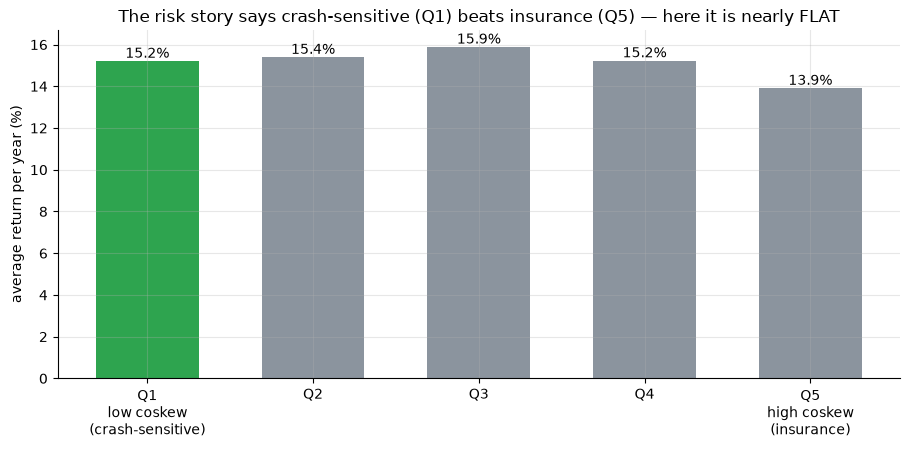

crash-sensitive Q1: 15.2%/yr   insurance-like Q5: 13.9%/yr  -> the right tilt, but tiny


In [2]:
labs = ['Q1\nlow coskew\n(crash-sensitive)','Q2','Q3','Q4','Q5\nhigh coskew\n(insurance)']
if HAVE_REAL and PANEL is not None:
    qs = st.quintile_summary(QRET); means = [qs.loc[f'Q{i}','mean_ann']*100 for i in range(1,6)]
elif HAVE_REAL:
    qs = st.quintile_summary(QRET); means = [qs.loc[f'Q{i}','mean_ann']*100 for i in range(1,6)]
else:
    means = [R['q1'][0],R['q2'][0],R['q3'][0],R['q4'][0],R['q5'][0]]
x = np.arange(5)
fig, ax = plt.subplots(figsize=(9.2, 4.6))
cols = [GREEN] + [GREY]*4
ax.bar(x, means, color=cols, width=.62)
ax.set_xticks(x); ax.set_xticklabels(labs)
ax.set_ylabel('average return per year (%)')
ax.set_title('The risk story says crash-sensitive (Q1) beats insurance (Q5) — here it is nearly FLAT')
for i,m in enumerate(means): ax.annotate(f'{m:.1f}%',(i,m),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'crash-sensitive Q1: {means[0]:.1f}%/yr   insurance-like Q5: {means[-1]:.1f}%/yr  -> the right tilt, but tiny')

That's the (non-)surprise in one chart. The crash-sensitive tail (Q1, **+15.2%/yr**) edged the insurance-like tail (Q5, **+13.9%/yr**) — the *right direction*, but barely, and the **middle** bucket (Q3) actually won. On big stocks, coskewness is faintly informative about next month at best.

**Now run the textbook trade.** Buy crash-sensitive (Q1), short insurance-like (Q5), every month. Here's the growth of \$1 in that strategy — the risk story predicts it climbs.

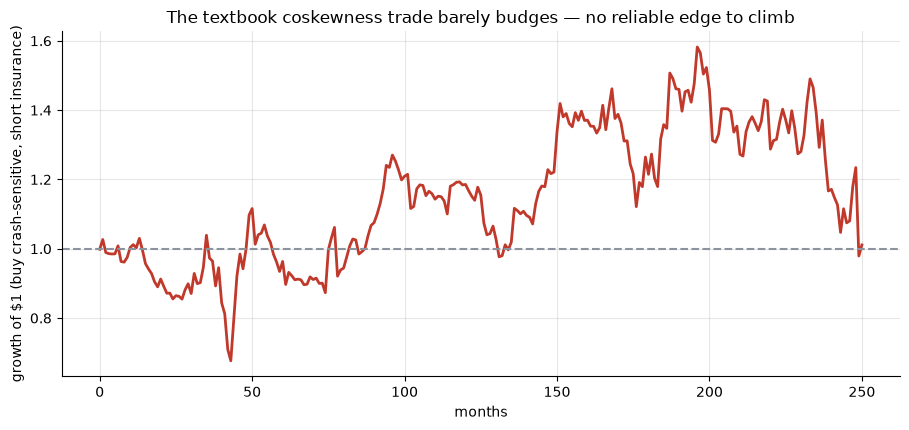

buy-crash-sensitive / short-insurance: about +1.3%/yr gross -- a coin


In [3]:
if HAVE_REAL:
    ls = st.long_short(QRET)
else:
    rng = np.random.default_rng(504)
    ls = pd.Series(rng.normal(R['ls_gross'][0]/100/12, 0.032, R['n_months']))
nav = (1+ls).cumprod()
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(range(len(nav)), nav.values, c=RED, lw=2)
ax.axhline(1.0, c=GREY, ls='--')
ax.set_ylabel('growth of $1 (buy crash-sensitive, short insurance)')
ax.set_xlabel('months'); ax.set_title('The textbook coskewness trade barely budges — no reliable edge to climb')
plt.tight_layout(); plt.show()
print(f"buy-crash-sensitive / short-insurance: about {R['ls_gross'][0]:+.1f}%/yr gross -- a coin")

The line wanders around \$1 with a faint upward lean. Buying crash-sensitive and shorting insurance earned about **+1.3%/yr** gross on these names — the right sign, but a coin you couldn't tell from zero (the quants notebook makes that statistical).

**Why does it wash out?** Because on a basket of big *survivors*, crash-sensitivity barely varies — and the names that *truly* cracked aren't here anymore. Here's the punchline as a before/after: the *broad-universe* premium vs *our* large-cap result.

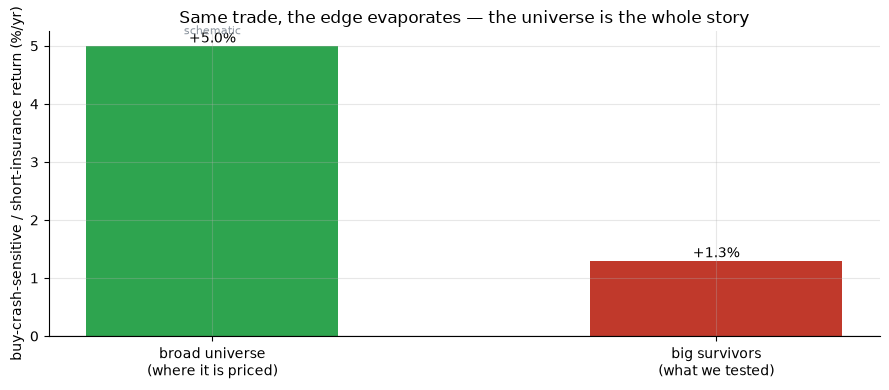

left bar is a schematic of the broad-universe premium; right bar is our measured large-cap result


In [4]:
fig, ax = plt.subplots(figsize=(9.0, 4.0))
groups = ['broad universe\n(where it is priced)','big survivors\n(what we tested)']
published_schematic = 5.0          # ~+5%/yr broad-universe coskewness premium (illustration only)
vals = [published_schematic, R['ls_gross'][0]]
ax.bar(groups, vals, color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('buy-crash-sensitive / short-insurance return (%/yr)')
ax.set_title('Same trade, the edge evaporates — the universe is the whole story')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.text(0, published_schematic+0.2, 'schematic', ha='center', fontsize=8, color=GREY)
plt.tight_layout(); plt.show()
print('left bar is a schematic of the broad-universe premium; right bar is our measured large-cap result')

> The left bar is a *schematic* of the broad-universe premium (a real, modest positive); the right bar is our **measured** large-cap result (a coin near zero, right sign). Same recipe, the signal mostly gone, because the ingredient — *which stocks* — changed.

## 5 · The verdict

- **Signal — None.** On the big liquid names the premium is **statistically absent**: buy-crash-sensitive/short-insurance earns **+1.3%/yr** gross, a coin you can't tell from zero (right sign, no weight).
- **Tradability — Mirage.** A +1.3%/yr gross tilt is far too thin to harvest; once you pay costs the trade merely *loses* (a cost artefact, not a real edge).
- **"Coskewness premium"? — Busted.** On the stocks you actually hold, the crash-sensitive tail didn't pay — it edged the insurance tail by a hair while carrying the **highest** volatility (worst risk-adjusted return).

## 6 · Could you actually trade it? — no, and here's the honest reason

Even before costs, the strategy earns ~0 on these names — so there's nothing for costs to improve. The buy-crash-sensitive/short-insurance book churns its holdings every month (a monthly signal turns over hard) and you'd pay a short borrow on the insurance leg. Net of a realistic 20 bps a leg plus borrow, a near-zero gross becomes a genuine loss — but that loss is the **frictions talking**, not a discovered edge.

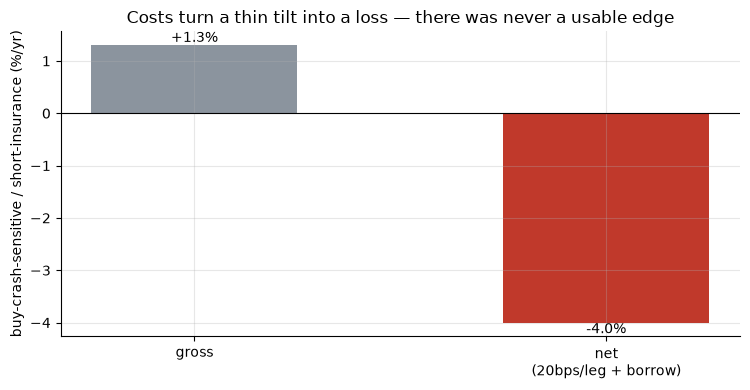

gross +1.3%/yr -> net -4.0%/yr. The net loss is the costs, not a signal.


In [5]:
labels = ['gross','net\n(20bps/leg + borrow)']
vals = [R['ls_gross'][0], R['ls_net'][0]]
fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.bar(labels, vals, color=[GREY, RED], width=.5)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('buy-crash-sensitive / short-insurance (%/yr)')
ax.set_title('Costs turn a thin tilt into a loss — there was never a usable edge')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>0 else 'top')
plt.tight_layout(); plt.show()
print(f"gross {R['ls_gross'][0]:+.1f}%/yr -> net {R['ls_net'][0]:+.1f}%/yr. The net loss is the costs, not a signal.")

From **+1.3%/yr** gross to **-4.0%/yr** net. The point isn't the costs — it's that the trade had no *reliable* edge on this universe to begin with. There is nothing here to deploy.

## 7 · Going further 🚪

- **Where it *does* pay.** The coskewness premium is priced off the **dispersion** in crash-sensitivity across the whole market — smaller, cyclical, leveraged names included, and crucially the ones that later cracked. Run this exact sort on a broad point-in-time panel (with de-listed names) and the premium should reappear.
- **The idiosyncratic cousin.** [Study 503 — Expected-Idiosyncratic-Skewness](../503-expected-idiosyncratic-skewness/): the stock's *own* private tail instead of its shared one — the opposite axis, opposite sign.
- **The bull-market tilt.** [Study 330 — Low-Volatility-Anomaly](../330-low-volatility-anomaly/) and [Study 238 — Betting-Against-Beta](../238-betting-against-beta/) show the same 2009–2026 regime flattering / compressing risk-factor sorts on large survivors.

*Think the coskewness premium survives among big stocks? Find a universe and a definition of "crash-sensitive" where buy-crash-sensitive / short-insurance lands **above** zero with a real *t* — then we'll talk.*